In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import os
from IPython.display import HTML
from scipy.signal import windows

In [2]:
hdf5_path = '/pscratch/sd/l/liyuzhi/lucio_files/beta_0p1/'
out = '/global/homes/l/liyuzhi/vpic/1dsheath_new/'
electron_name = 'electron'
ion_name = 'ion'
field_name = 'fields'
begin_timestep = 10000
time_interval = 2
end_timestep = 140000
me = 1.0
mi = 100.0 # 2003.0 # 1836.0 # 36777.0

In [3]:
lx = 512.0
nx = 2048
nt = end_timestep - begin_timestep

Te = 50
x_axis = np.linspace(0,lx,nx)
dx = x_axis[1] - x_axis[0]
lambda_D = 1.0
w_p = np.sqrt(Te)
cvac = 10*np.sqrt(Te)
d_e = cvac/w_p
dg = 1/np.sqrt(1/0.25/0.25 + 1/0.5/0.5 + 1/0.5/0.5)
dt = 0.97*dg/cvac
lt = nt*dt

In [4]:
def load_field(var):
    for tindex in range(begin_timestep,end_timestep,time_interval):
        if (var+str(tindex)) not in bvec:
            fname = (hdf5_path + "field_hdf5/T." + str(tindex) +
               "/fields_" + str(tindex) + ".h5")
            with h5py.File(fname, 'r') as fh:
                group = fh["Timestep_" + str(tindex)]
                bvec[var+str(tindex)] = group[var][()][::]
    return bvec

import numpy as np

def field_fft(var, bvec):
    xf = 2 * np.pi * np.fft.fftfreq(Nx, Tx)[:Nx//2]
    tf = 2 * np.pi * np.fft.fftfreq(Nt, Tt)[:Nt//2]

    slices = [
        bvec[f"{var}{tindex}"][:, 0:1, 0] 
        for tindex in range(begin_timestep, end_timestep, time_interval)
    ]
    
    data = np.concatenate(slices, axis=1)
    
    data = data - np.mean(data, axis=1, keepdims=True)
    
    data *= np.blackman(data.shape[1])
    
    return np.fft.fft2(data)

def reduce_space(bvec,reduce_factor):
    bvec_small={}
    # for vartime in bvec:
    #     bvec_small[vartime]=bvec[vartime][::reduce_factor,:,:]
    for vartime in bvec:
        bvec_small[vartime]=sum([bvec[vartime][i::reduce_factor,:,:]/reduce_factor for i in range(reduce_factor)])
    return bvec_small



In [5]:
# read fields
bvec = {}
Bz_label ='cbz'
#By_label = 'cby'
#By = load_field(By_label)
Bz = load_field(Bz_label)

In [6]:
def get_bx():
    label = 'cbx'
    fname = (hdf5_path + "field_hdf5/T." + str(begin_timestep) +
               "/fields_" + str(begin_timestep) + ".h5")
    with h5py.File(fname, 'r') as fh:
        group = fh["Timestep_" + str(begin_timestep)]
        Bx = group[label][()][::]
    return Bx[0]
Bx = get_bx()
w_c = np.mean(Bx)/cvac
VA = np.mean(Bx)/cvac/np.sqrt(5.436e-6 * 101 * 1840)

In [12]:
w_p/w_c

np.float64(2.236067992353095)

In [14]:
Nx=nx;Tx=dx;
Nt = (end_timestep-begin_timestep)//time_interval
Tt=time_interval*dt;
vartime=Bz_label+str(begin_timestep)
fieldf={}
fieldf[vartime]=field_fft(Bz_label,bvec)

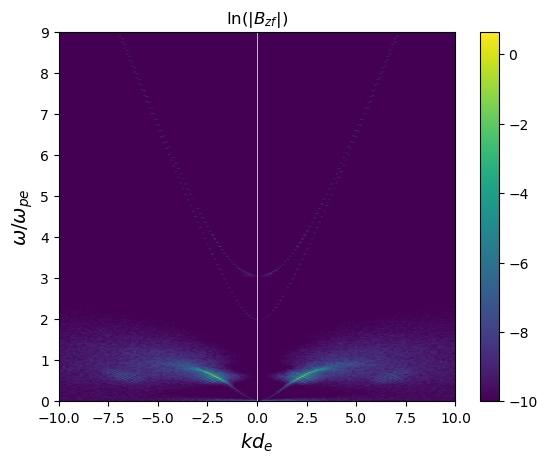

In [16]:
def plot_fft_fullk(Nx,Tx,**kwargs):
    fieldf_shift=np.fft.fftshift(fieldf[vartime],axes=0)
    xf=2*np.pi*np.fft.fftfreq(Nx, Tx)[:Nx//2] * d_e
    tf=2*np.pi*np.fft.fftfreq(Nt, Tt)[:Nt//2] / w_p
#     print(tf[-1])
    plt.imshow(np.log(2/Nx/Nt*abs(fieldf_shift[:,:Nt//2].T)), extent=[-xf[-1],xf[-1],tf[0],tf[-1]],origin='lower',aspect='auto',**kwargs) 
    plt.colorbar()
    plt.plot([0]*2,[0,9],color='w',linewidth=0.5)
    plt.ylabel(r'$\omega/\omega_{pe}$',fontsize=14)
    plt.xlabel(r'$kd_e$',fontsize=14)
#     plt.title(r'ln(|{}_f|) ninterval='.format(var)+str(Nskip//interval))
    plt.title(r'ln(|$B_{zf}$|)')
    #print(f'interval {begin_timestep//time_interval}')
    plt.ylim(0,9)
    plt.xlim(-10,10)
plot_fft_fullk(Nx=Nx,Tx=Tx,vmin=-10)

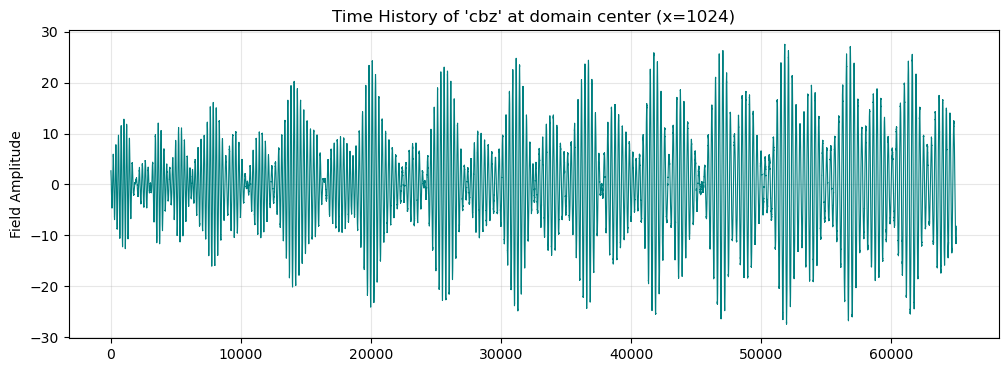

In [19]:
import matplotlib.pyplot as plt

time_history = []

first_key = Bz_label + str(begin_timestep)
mid_x = Bz[first_key].shape[0] // 2


for tindex in range(begin_timestep, end_timestep, time_interval):
    key = Bz_label + str(tindex)
    
    val = Bz[key][mid_x, 0, 0]
    time_history.append(val)

# Plot the result
plt.figure(figsize=(12, 4))
plt.plot(time_history, linewidth=0.8, color='teal')
plt.title(f"Time History of '{Bz_label}' at domain center (x={mid_x})")
#plt.xlabel("Time Sample Index (0 to 300,000)")
plt.ylabel("Field Amplitude")
plt.grid(True, alpha=0.3)
plt.show()